In [5]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
df = pd.read_excel(r"C:\Users\Neethu\Documents\ML\Department Awareness Survey (Responses).xlsx")

In [7]:
# Data Preprocessing
print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nMISSING VALUES")
print(df.isnull().sum())

FIRST 5 ROWS
                Timestamp Registration Number   \
0 2026-06-22 08:49:31.362              2547123   
1 2026-06-22 08:49:50.520              2547122   
2 2026-06-22 08:50:44.521              2547101   
3 2026-06-22 08:51:00.666              2547156   
4 2026-06-22 08:51:42.357              2547148   

                                          Email  \
0         jiyaelza.jabi@mca.christuniversity.in   
1  jinishaleema.rosario@mca.christuniversity.in   
2        rajeev.chandar@mca.christuniversity.in   
3    sounak.chakraborty@mca.christuniversity.in   
4         samar.subhash@mca.christuniversity.in   

  Job role that you are interested in\n  \
0                     Software Engineer   
1                         Data Engineer   
2                     Software Engineer   
3                        Data Scientist   
4                     Software Engineer   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                       

In [8]:
# Remove missing and duplicate values
df = df.dropna()
df = df.drop_duplicates()

In [9]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(54, 15)


In [10]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Timestamp', 'Registration Number ', 'Email', 'Job role that you are interested in\n', 'What is the minimum salary of students placed through campus (In LPA..respond as a number)', 'What is the maximum salary of students placed through campus (In LPA..respond as a number)', 'What is the  median salary of students placed through campus (In LPA..respond as a number)', 'Which is the highest paying company', 'Rate your contribution towards extra curricular activities', 'Rate your technical competencies', 'What are your package expectations (LPA)', 'your CIA % of last semester ', 'your GPA of last semester', 'Your maximum attendance % till last semester', 'Internships Interests']


In [11]:
print(df.isnull().sum())

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

In [12]:
df = df.dropna()

In [13]:
df = df.drop_duplicates()

In [14]:
print(df.describe())

                        Timestamp  \
count                          54   
mean   2026-06-22 08:53:31.366499   
min    2026-06-22 08:49:31.362000   
25%    2026-06-22 08:52:20.128750   
50%    2026-06-22 08:53:30.697500   
75%    2026-06-22 08:54:18.161750   
max    2026-06-22 08:57:57.108000   
std                           NaN   

       Rate your contribution towards extra curricular activities  \
count                                          54.000000            
mean                                            3.592593            
min                                             2.000000            
25%                                             3.000000            
50%                                             4.000000            
75%                                             4.000000            
max                                             5.000000            
std                                             0.981307            

       Rate your technical competencies  
co

In [15]:
# Actual column names from your dataset
CIA_COL = "your CIA % of last semester "
ATTENDANCE_COL = "Your maximum attendance % till last semester"
GPA_COL = "your GPA of last semester"

In [16]:
# Convert to numeric
df[CIA_COL] = pd.to_numeric(df[CIA_COL], errors="coerce")
df[ATTENDANCE_COL] = pd.to_numeric(df[ATTENDANCE_COL], errors="coerce")
df[GPA_COL] = pd.to_numeric(df[GPA_COL], errors="coerce")

df = df.dropna()

print("\nStatistical Summary")
print(df[[CIA_COL, ATTENDANCE_COL, GPA_COL]].describe())



Statistical Summary


       your CIA % of last semester   \
count                     46.000000   
mean                      58.326763   
std                       30.939425   
min                        0.630000   
25%                       65.002500   
50%                       70.000000   
75%                       78.000000   
max                       89.000000   

       Your maximum attendance % till last semester  your GPA of last semester  
count                                     46.000000                  46.000000  
mean                                      79.100402                   5.623913  
std                                       33.757066                  12.769951  
min                                        0.870000                   2.900000  
25%                                       86.250000                   3.400000  
50%                                       92.000000                   3.505000  
75%                                       96.750000                   3.730000  

In [17]:
# EXPERIMENT 1
# CIA % -> GPA


print("\n EXPERIMENT 1 ")

X = df[[CIA_COL]]
Y = df[GPA_COL]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, Y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("\nScikit Learn Results")
print("Slope =", slope)
print("Intercept =", intercept)

print("\nRegression Equation")
print(f"GPA = ({slope:.4f} * CIA) + ({intercept:.4f})")

predictions = model.predict(X_test)

print("\nFirst 5 Predictions")
print(predictions[:5])

print("\nInterpretation")
if slope > 0:
    print(f"For every 1% increase in CIA, GPA increases by approximately {slope:.4f}.")
else:
    print(f"For every 1% increase in CIA, GPA decreases by approximately {abs(slope):.4f}.")



 EXPERIMENT 1 

Scikit Learn Results
Slope = 0.06867502407800606
Intercept = 1.657904973456076

Regression Equation
GPA = (0.0687 * CIA) + (1.6579)

First 5 Predictions
[1.93260507 1.71078474 7.1519069  7.56395704 6.46515666]

Interpretation
For every 1% increase in CIA, GPA increases by approximately 0.0687.


In [18]:
# MANUAL OLS

x = df[CIA_COL].values
y = df[GPA_COL].values

x_mean = np.mean(x)
y_mean = np.mean(y)

m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)

c = y_mean - (m * x_mean)

print("Manual Slope =", m)
print("Manual Intercept =", c)

manual_predictions = m * X_test.values.flatten() + c

Manual Slope = 0.04549568813574868
Manual Intercept = 2.970296822084463


In [19]:
# COMPARISON

comparison = pd.DataFrame({
    "Scikit Prediction": predictions,
    "Manual Prediction": manual_predictions
})

comparison["Difference"] = abs(
    comparison["Scikit Prediction"] -
    comparison["Manual Prediction"]
)

print("\nComparison")
print(comparison.head())

print("\nObservation")
print("Scikit-Learn and Manual OLS give nearly identical results.")



Comparison
   Scikit Prediction  Manual Prediction  Difference
0           1.932605           3.152280    1.219675
1           1.710785           3.005329    1.294544
2           7.151907           6.609952    0.541955
3           7.563957           6.882926    0.681031
4           6.465157           6.154995    0.310162

Observation
Scikit-Learn and Manual OLS give nearly identical results.


In [20]:
X = df[[ATTENDANCE_COL]]
Y = df[GPA_COL]

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[[ATTENDANCE_COL]]
Y = df[GPA_COL]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, Y_train)

print("Slope =", model2.coef_[0])
print("Intercept =", model2.intercept_)

print("\nRegression Equation")
print(
    f"GPA = ({model2.coef_[0]:.4f} × Attendance) + ({model2.intercept_:.4f})"
)

predictions2 = model2.predict(X_test)

print("\nPredictions")
print(predictions2[:5])

Slope = 0.011319297583765762
Intercept = 4.984252420000036

Regression Equation
GPA = (0.0113 × Attendance) + (4.9843)

Predictions
[6.11618218 4.99523214 6.07090499 5.95771201 5.9916699 ]


In [22]:
if model2.coef_[0] > 0:
    print("Attendance and GPA have a positive relationship.")
    print(
        f"For every 1% increase in attendance, GPA increases by approximately {model2.coef_[0]:.4f}."
    )
else:
    print("Attendance and GPA have a negative relationship.")

Attendance and GPA have a positive relationship.
For every 1% increase in attendance, GPA increases by approximately 0.0113.


In [23]:
correlation = df[ATTENDANCE_COL].corr(df[GPA_COL])

print("Correlation =", round(correlation, 4))

Correlation = 0.0332


In [24]:
if correlation > 0:
    print("Positive correlation exists between Attendance and GPA.")
elif correlation < 0:
    print("Negative correlation exists between Attendance and GPA.")
else:
    print("No correlation exists.")

Positive correlation exists between Attendance and GPA.


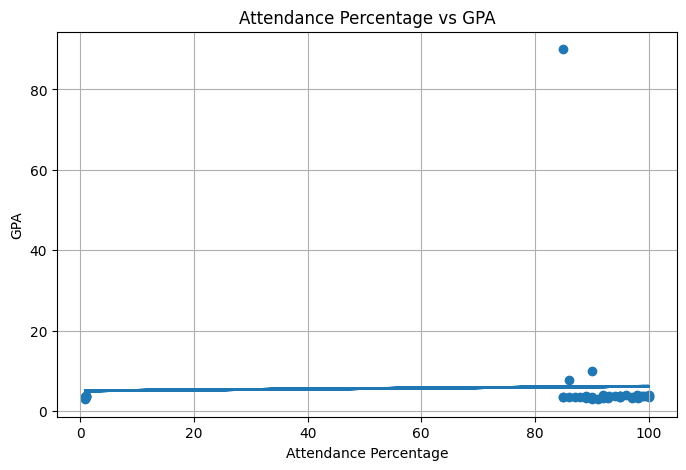

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df[ATTENDANCE_COL], df[GPA_COL])

plt.plot(
    df[ATTENDANCE_COL],
    model2.predict(df[[ATTENDANCE_COL]]),
    linewidth=2
)

plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Attendance Percentage vs GPA")

plt.grid(True)
plt.show()

In [26]:
import pickle

parameters = {
    "slope": model2.coef_[0],
    "intercept": model2.intercept_
}

with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(parameters, file)

print("Parameters Saved Successfully")

Parameters Saved Successfully


In [27]:
with open("linear_regression_weights.pkl", "rb") as file:
    loaded = pickle.load(file)

print("Loaded Parameters")
print(loaded)

Loaded Parameters
{'slope': np.float64(0.011319297583765762), 'intercept': np.float64(4.984252420000036)}


In [28]:
new_attendance = 90

predicted_gpa = (
    loaded["slope"] * new_attendance +
    loaded["intercept"]
)

print("Predicted GPA =", predicted_gpa)

Predicted GPA = 6.002989202538955


In [29]:
print("\nFINAL OBSERVATION")

print("The dataset was successfully preprocessed.")
print("Simple Linear Regression was implemented using Scikit-Learn and Manual OLS.")
print("CIA Percentage and Attendance Percentage were used to predict GPA.")
print("Both methods produced nearly identical results.")
print("Model parameters were successfully saved and loaded using Pickle.")
print("The scatter plots and correlation values showed the relationship between variables.")


FINAL OBSERVATION
The dataset was successfully preprocessed.
Simple Linear Regression was implemented using Scikit-Learn and Manual OLS.
CIA Percentage and Attendance Percentage were used to predict GPA.
Both methods produced nearly identical results.
Model parameters were successfully saved and loaded using Pickle.
The scatter plots and correlation values showed the relationship between variables.


In [31]:
CIA_COL = "your CIA % of last semester "
ATTENDANCE_COL = "Your maximum attendance % till last semester"
GPA_COL = "your GPA of last semester"